# DMW methylation matrices by genotype

**Self-contained.** Extracts DMW methylation matrices for **each genotype (col, rdd, met)** from the single shared MCDS, and produces a per-genotype clustermap.

Genotype is encoded in the cell ID: `240614_mct_<G>_<plate>_<well>` where `G ∈ {1=col, 2=rdd, 3=met}`. The MCDS itself has no explicit `genotype` coordinate.

For each genotype, two matrices are written:

| Output | Contents |
|---|---|
| `<geno>_dmw_raw_methylation.tsv` | observed methylation fraction per cluster, `obs_p = mc / cov` |
| `<geno>_dmw_residual_methylation.tsv` | per-cluster-adjusted residual, `obs_p − p0` |

Both are **DMW × 17 merged clusters**, un-z-scored. The clustermap z-scores each row for color stability; z-scoring discards original units, so the TSVs are saved pre-z-score.

**Row set:** the canonical 3,054 curated CG chunks defined by col-0 coverage + highly-methylated filters. The same DMWs are used for all three genotypes so heatmaps are directly comparable row-for-row, though the row dendrogram is fit per genotype so the visual order differs.

**Per-cluster logit offsets (`deltas`) are re-fit per genotype**, so each genotype's residual is the cluster-specific deviation from THAT genotype's mean — not from col-0's mean. This makes the residual heatmap show within-genotype cluster structure rather than overall mutant methylation loss.


In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.special import logit, expit
from ALLCools.mcds import MCDS


In [2]:
# --------------------------- PATHS / CONSTANTS ---------------------------
MCDS_PATHS = [
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_0.mcds",
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_1.mcds",
]
CHUNKS_GFF = "/ceph/MethDev/pbio/andy/JW/section_4/chunks_CG_minfilt.gff"
META_PATH  = "/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv"

OUTDIR     = "/ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype"
FIG_OUTDIR = "/ceph/MethDev/pbio/kay/figures/heatmaps"
os.makedirs(OUTDIR,     exist_ok=True)
os.makedirs(FIG_OUTDIR, exist_ok=True)

MC_TYPE      = "CGN"   # methylation context to extract
MIN_COV      = 50      # per-DMW summed-coverage filter (applied per genotype)
HIGH_METH_TH = 0.10    # used on col-0 to define the canonical row set

# Genotype is encoded in the 2nd underscore-field of the cell ID:
# 240614_mct_<G>_<plate>_<well>   →  1=col, 2=rdd, 3=met
GENOTYPE_MAP = {"1": "col", "2": "rdd", "3": "met"}
GENOTYPES    = ["col", "rdd", "met"]

cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 1: '1 Late M', 7: '7 Expanding M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem',
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase',
}
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem',
    '16 Myrosinase', '12 S phase', '15 G2M phase',
]


In [3]:
# ----- Load MCDS, curated chunks, cell-cluster metadata -----
mcds = MCDS.open(mcds_paths=MCDS_PATHS, var_dim="dmw")
meta = pd.read_csv(META_PATH).set_index("cell_id")
print(f"MCDS dims: {dict(mcds.dims)}")
print(f"Cells with merged-cluster metadata: {len(meta)}")

# Curated CG chunks (file is 0-based BED-style despite the .gff name;
# +1 to start aligns it with the 1-based MCDS coords)
chunks = pd.read_csv(
    CHUNKS_GFF, sep="\t", header=None, comment="#",
    usecols=[0, 3, 4], names=["chrom", "start", "end"],
)
chunks["chrom"] = chunks["chrom"].str.replace("^chr", "", regex=True)
chunks["start"] = chunks["start"].astype(int) + 1
chunks["end"]   = chunks["end"].astype(int)

# Match against MCDS DMW table and keep matching dmw_ids
mcds_bed = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values.astype(str),
    "start":  mcds["dmw_start"].values.astype(int),
    "end":    mcds["dmw_end"].values.astype(int),
    "dmw_id": mcds.get_index("dmw").values,
})
keep = mcds_bed.merge(chunks, on=["chrom", "start", "end"], how="inner")
print(f"Curated chunks matched: {len(keep)} / {len(chunks)}")
mcds = mcds.sel(dmw=keep["dmw_id"].tolist())
print(f"Filtered MCDS dims:    {dict(mcds.dims)}")

# Derive genotype per cell from the 2nd underscore field of the cell ID
genotype_per_cell = (
    pd.Series(mcds["cell"].values, index=mcds["cell"].values)
    .str.split("_").str[2]
    .map(GENOTYPE_MAP)
)
print("\nGenotype counts (all MCDS cells):")
print(genotype_per_cell.value_counts())


MCDS dims: {'cell': 6071, 'count_type': 2, 'dmw': 22467, 'mc_type': 4}
Cells with merged-cluster metadata: 5908
Curated chunks matched: 3124 / 3124
Filtered MCDS dims:    {'cell': 6071, 'count_type': 2, 'dmw': 3124, 'mc_type': 4}

Genotype counts (all MCDS cells):
col    3059
met    1532
rdd    1480
Name: count, dtype: int64


In [4]:
mcds

<xarray.MCDS>
Dimensions:      (cell: 6071, count_type: 2, dmw: 3124, mc_type: 4)
Coordinates:
  * cell         (cell) <U27 '240614_mct_1_1_P2-4-E5-M20' ... '240614_mct_1_3...
  * count_type   (count_type) <U3 'mc' 'cov'
  * dmw          (dmw) <U9 'dmw=9' 'dmw=44' 'dmw=45' ... 'dmw=22457' 'dmw=22463'
    dmw_chrom    (dmw) int64 1 1 1 1 1 1 1 1 1 1 1 1 ... 5 5 5 5 5 5 5 5 5 5 5 5
    dmw_end      (dmw) int64 77300 282200 282800 ... 26886400 26886900 26945700
    dmw_start    (dmw) int64 76801 281801 282601 ... 26885901 26886601 26945501
  * mc_type      (mc_type) <U3 'CHH' 'CHG' 'CHN' 'CGN'
    strand_type  <U4 'both'
Data variables:
    dmw_da       (cell, dmw, mc_type, count_type) uint32 dask.array<chunksize=(190, 280, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  dmw

In [5]:
# ----- Per-cluster mc/cov aggregation, factored out so we can call per genotype -----
mc_cell  = mcds.sel(mc_type=MC_TYPE, count_type="mc" ).dmw_da.to_pandas()
cov_cell = mcds.sel(mc_type=MC_TYPE, count_type="cov").dmw_da.to_pandas()

# Restrict to cells with a merged-cluster assignment AND a recognized genotype
shared_cells = mc_cell.index.intersection(meta.index).intersection(genotype_per_cell.dropna().index)
mc_cell     = mc_cell.loc[shared_cells]
cov_cell    = cov_cell.loc[shared_cells]
cluster_of  = meta.loc[shared_cells, "merged_cluster"]
genotype_of = genotype_per_cell.loc[shared_cells]

print(f"Cells with cluster + genotype labels: {len(shared_cells)}")
print(genotype_of.value_counts())

def per_cluster_sums(genotype):
    """Aggregate (mc, cov) per (DMW, cluster) for the cells of one genotype."""
    cells = shared_cells[genotype_of == genotype]
    mc_g  = mc_cell.loc[cells].copy()
    cov_g = cov_cell.loc[cells].copy()
    mc_g ["cluster"] = cluster_of.loc[cells]
    cov_g["cluster"] = cluster_of.loc[cells]
    c = mc_g .groupby("cluster").sum().T   # DMW x cluster (mc)
    m = cov_g.groupby("cluster").sum().T   # DMW x cluster (cov)
    return c, m


Cells with cluster + genotype labels: 5908
col    2938
met    1521
rdd    1449
Name: count, dtype: int64


In [6]:
# ----- Compute residuals per genotype, then anchor all to col-0's row set -----
def compute_matrices(cluster_c, cluster_m):
    """Fit per-cluster logit offsets and return (obs_p, residual) for one genotype."""
    global_c = cluster_c.sum(axis=0)
    global_m = cluster_m.sum(axis=0)
    global_p = global_c / global_m
    d        = logit(np.clip(global_p, 1e-6, 1 - 1e-6))
    deltas   = d - np.average(d, weights=global_m)

    # Per-DMW summed coverage filter (per genotype)
    dmw_m = cluster_m.sum(axis=1)
    valid = dmw_m >= MIN_COV
    cluster_c = cluster_c[valid]
    cluster_m = cluster_m[valid]
    dmw_c = cluster_c.sum(axis=1)
    dmw_m = dmw_m[valid]

    pbar = np.clip(dmw_c / dmw_m, 1e-6, 1 - 1e-6)
    expected = logit(pbar).values[:, None] + deltas.values[None, :]
    p0 = pd.DataFrame(expit(expected), index=cluster_c.index, columns=cluster_c.columns)

    obs_p    = (cluster_c / cluster_m.replace(0, np.nan)).fillna(0)
    residual = obs_p - p0
    return obs_p, residual

raw_by_geno = {}
res_by_geno = {}
for g in GENOTYPES:
    c, m = per_cluster_sums(g)
    obs_p, residual = compute_matrices(c, m)
    raw_by_geno[g] = obs_p
    res_by_geno[g] = residual
    print(f"{g}: DMWs passing per-genotype coverage filter (sum cov >= {MIN_COV}): {obs_p.shape[0]}")

# Canonical row set: col-0 highly-methylated DMWs (>= HIGH_METH_TH in any cluster)
canonical_rows = raw_by_geno["col"][
    (raw_by_geno["col"] >= HIGH_METH_TH).any(axis=1)
].index
print(f"\nCanonical row set (col-0 highly-methylated, >= {HIGH_METH_TH} in any cluster): {len(canonical_rows)} DMWs")

# Anchor every genotype to the canonical row set.
# Any DMW that fails a mutant's coverage filter is filled with NaN so all
# three matrices share identical row indices for direct comparison.
for g in GENOTYPES:
    raw_by_geno[g] = raw_by_geno[g].reindex(canonical_rows)
    res_by_geno[g] = res_by_geno[g].reindex(canonical_rows)
    n_missing = raw_by_geno[g].isna().any(axis=1).sum()
    print(f"{g}: rows after anchoring = {raw_by_geno[g].shape[0]}  (NaN rows from low coverage: {n_missing})")


col: DMWs passing per-genotype coverage filter (sum cov >= 50): 3124
rdd: DMWs passing per-genotype coverage filter (sum cov >= 50): 3116
met: DMWs passing per-genotype coverage filter (sum cov >= 50): 3124

Canonical row set (col-0 highly-methylated, >= 0.1 in any cluster): 3088 DMWs
col: rows after anchoring = 3088  (NaN rows from low coverage: 0)
rdd: rows after anchoring = 3088  (NaN rows from low coverage: 8)
met: rows after anchoring = 3088  (NaN rows from low coverage: 0)


In [7]:
# ----- Relabel cluster columns, reorder, save TSVs (one pair per genotype) -----
def relabel(df):
    df = df.rename(columns=cluster_mapping)
    return df[[c for c in cluster_order if c in df.columns]]

raw_relabeled = {g: relabel(raw_by_geno[g]) for g in GENOTYPES}
res_relabeled = {g: relabel(res_by_geno[g]) for g in GENOTYPES}

for g in GENOTYPES:
    raw_path = f"{OUTDIR}/{g}_dmw_raw_methylation.tsv"
    res_path = f"{OUTDIR}/{g}_dmw_residual_methylation.tsv"
    raw_relabeled[g].to_csv(raw_path, sep="\t")
    res_relabeled[g].to_csv(res_path, sep="\t")
    raw_finite = raw_relabeled[g].to_numpy()
    res_finite = res_relabeled[g].to_numpy()
    raw_finite = raw_finite[np.isfinite(raw_finite)]
    res_finite = res_finite[np.isfinite(res_finite)]
    print(f"{g}: raw      {raw_relabeled[g].shape}  → {raw_path}")
    print(f"     range: [{raw_finite.min():.3f}, {raw_finite.max():.3f}]")
    print(f"{g}: residual {res_relabeled[g].shape}  → {res_path}")
    print(f"     range: [{res_finite.min():+.3f}, {res_finite.max():+.3f}]")


col: raw      (3088, 17)  → /ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype/col_dmw_raw_methylation.tsv
     range: [0.000, 1.000]
col: residual (3088, 17)  → /ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype/col_dmw_residual_methylation.tsv
     range: [-0.945, +0.796]
rdd: raw      (3088, 17)  → /ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype/rdd_dmw_raw_methylation.tsv
     range: [0.000, 1.000]
rdd: residual (3088, 17)  → /ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype/rdd_dmw_residual_methylation.tsv
     range: [-0.985, +0.924]
met: raw      (3088, 17)  → /ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype/met_dmw_raw_methylation.tsv
     range: [0.000, 1.000]
met: residual (3088, 17)  → /ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype/met_dmw_residual_methylation.tsv
     range: [-0.950, +0.997]



--- Clustermap: col ---
col: clustering 3088 DMWs across 17 clusters (dropped 0 rows with NaNs)


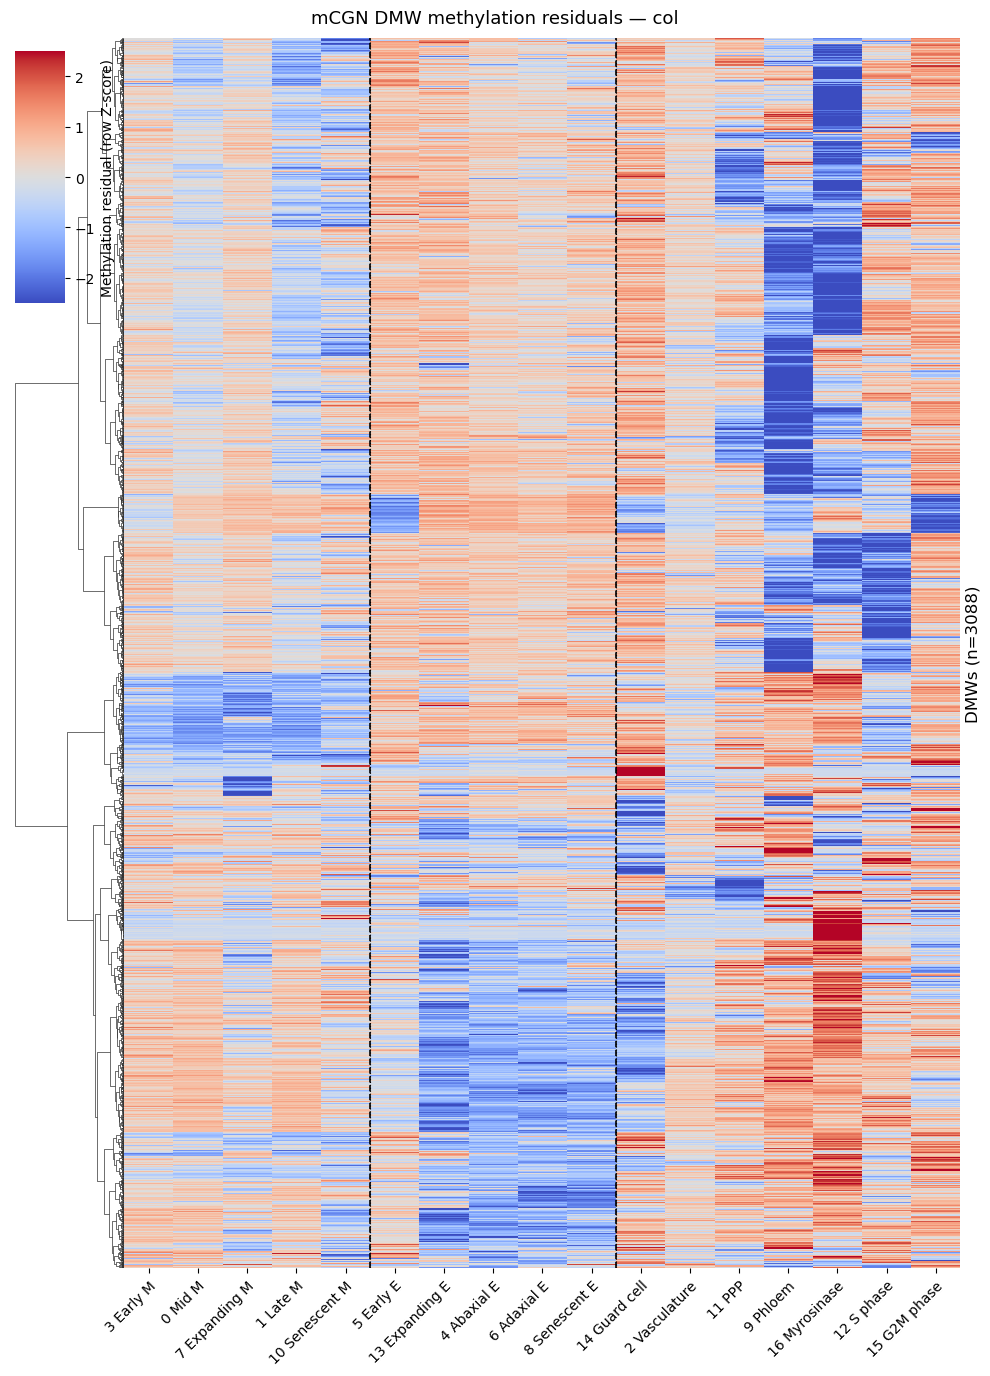


--- Clustermap: rdd ---
rdd: clustering 3080 DMWs across 17 clusters (dropped 8 rows with NaNs)


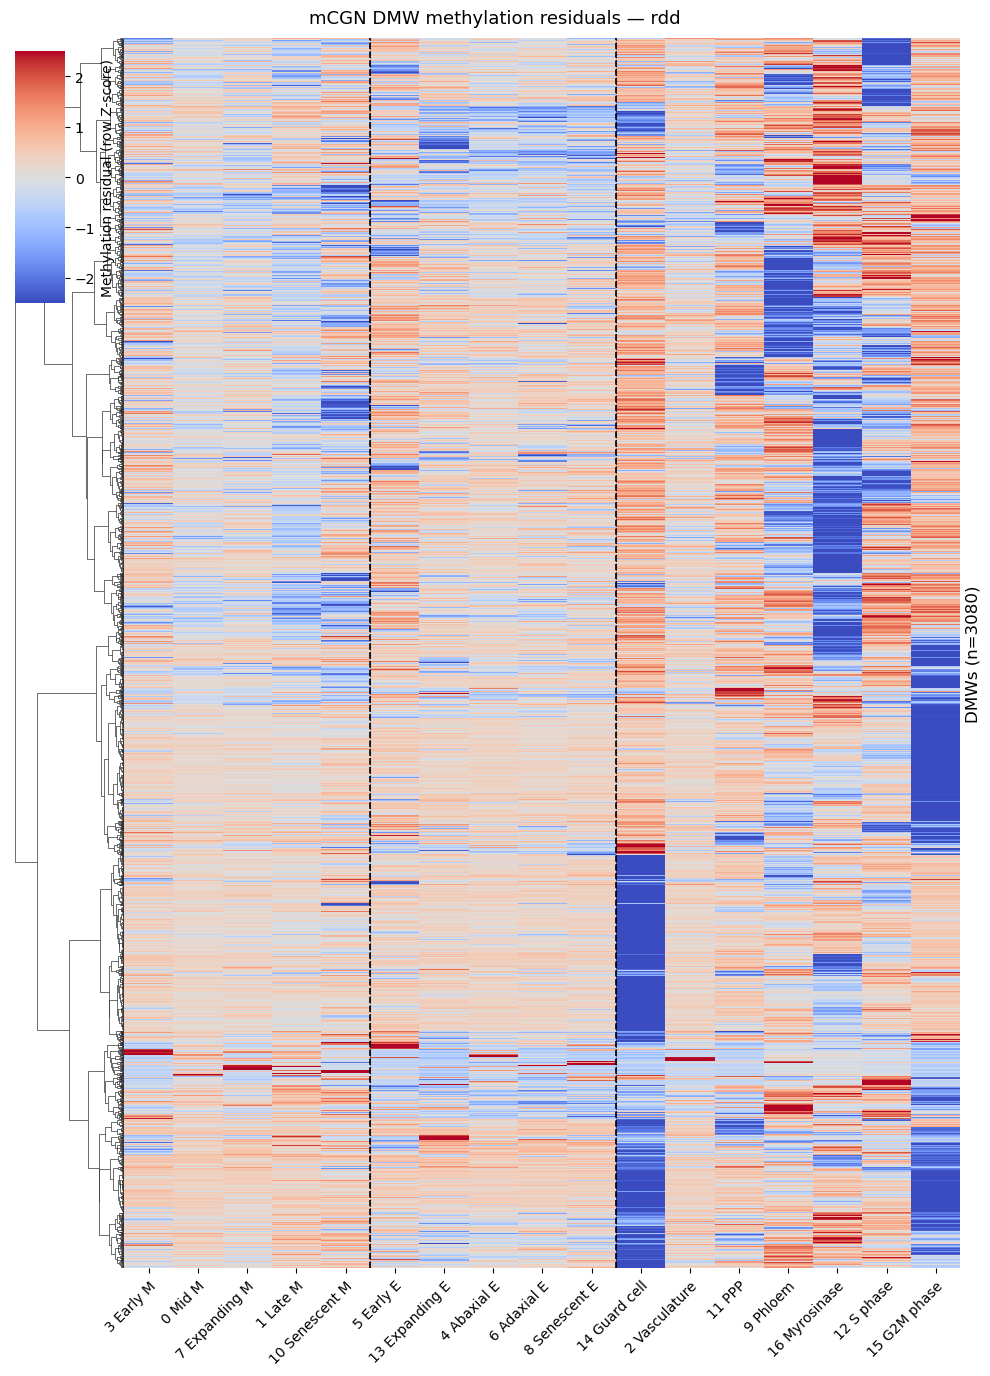


--- Clustermap: met ---
met: clustering 3088 DMWs across 17 clusters (dropped 0 rows with NaNs)


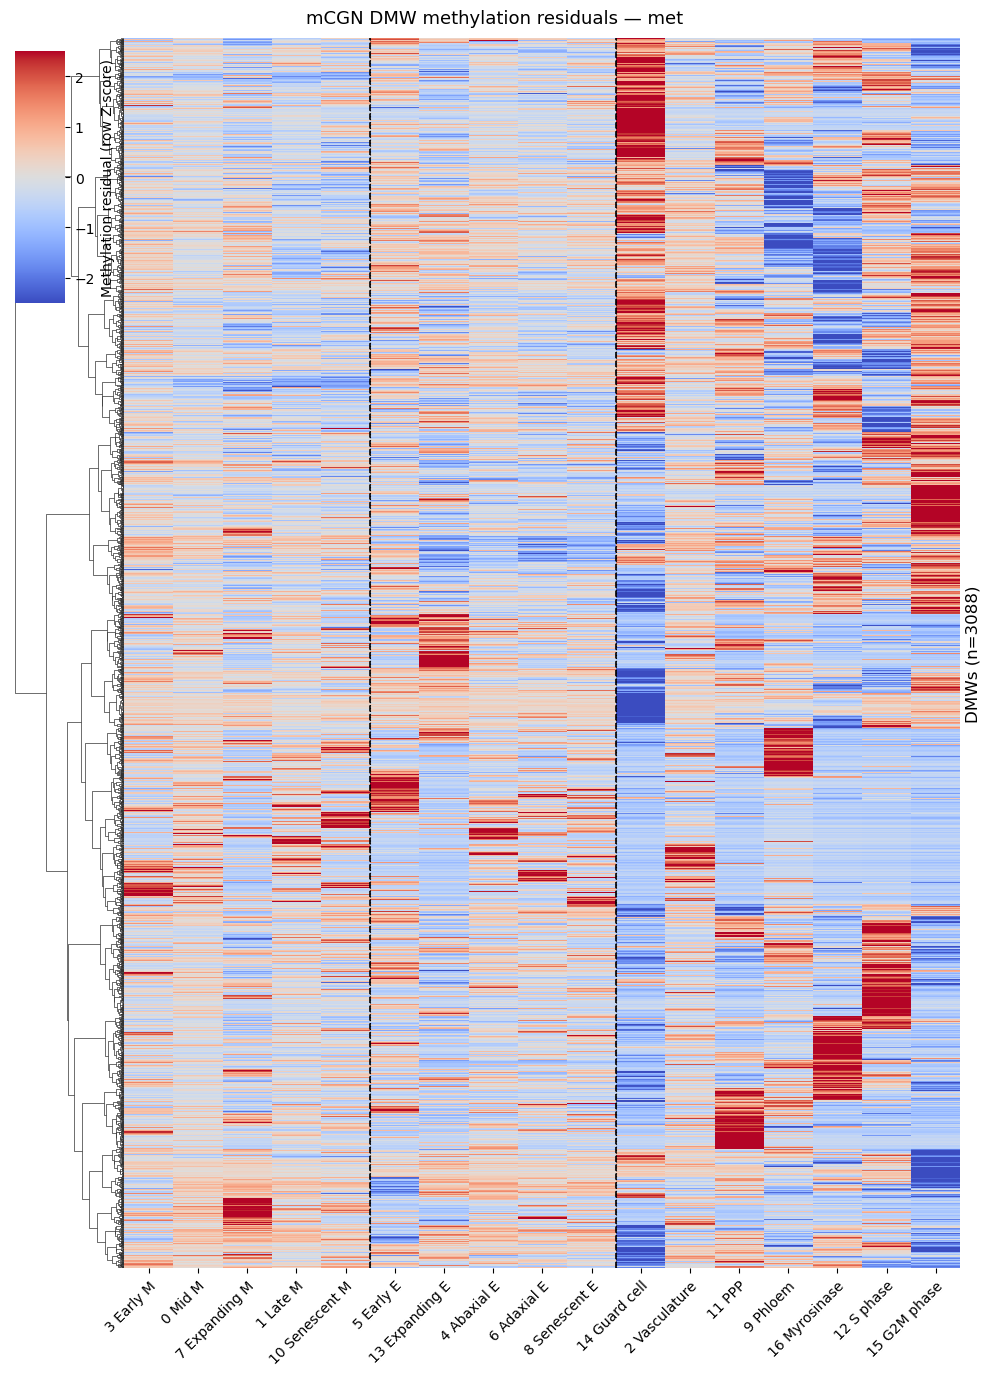

In [8]:
# ----- Per-genotype clustermap (rows independently clustered for each genotype) -----
# Z-scoring is for color stability; the saved TSVs are NOT z-scored.
def plot_clustermap(residual_df, genotype):
    # Drop rows with NaNs (genotype-specific coverage failures) before clustering
    df_complete = residual_df.dropna()
    vis = df_complete.apply(zscore, axis=1).clip(lower=-2.5, upper=2.5)
    print(f"{genotype}: clustering {len(vis)} DMWs across {vis.shape[1]} clusters "
          f"(dropped {len(residual_df) - len(vis)} rows with NaNs)")

    g = sns.clustermap(
        vis,
        cmap="coolwarm", center=0,
        row_cluster=True, col_cluster=False,
        method="ward", metric="euclidean",
        yticklabels=False,
        figsize=(10, 14),
        cbar_kws={"label": "Methylation residual (row Z-score)"},
        dendrogram_ratio=(0.12, 0.0),
    )
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(),
                                 rotation=45, ha="right", rotation_mode="anchor")
    g.ax_heatmap.set_ylabel(f"DMWs (n={len(vis)})", fontsize=12)
    g.ax_heatmap.set_xlabel("")
    g.fig.suptitle(f"m{MC_TYPE} DMW methylation residuals — {genotype}",
                   fontsize=13, y=1.01)

    mesophyll_end = sum(1 for c in vis.columns if c.endswith(" M"))
    epidermis_end = mesophyll_end + sum(1 for c in vis.columns if c.endswith(" E"))
    for pos in (mesophyll_end, epidermis_end):
        g.ax_heatmap.axvline(pos, color="black", lw=1.2, linestyle="--")
    for i, col_name in enumerate(vis.columns):
        if "Senescent M" in col_name or "Senescent E" in col_name:
            g.ax_heatmap.axvline(i + 1, color="black", lw=0.8, linestyle=":")

    out_path = f"{FIG_OUTDIR}/{genotype}_curated_dmws_residual_clustermap.png"
    #g.savefig(out_path, dpi=300, bbox_inches="tight")
    #print(f"Saved heatmap: {out_path}")
    plt.show()

for g in GENOTYPES:
    print(f"\n--- Clustermap: {g} ---")
    plot_clustermap(res_relabeled[g], g)


In [9]:
# ----- Preview output matrices (first 3 DMWs each) -----
for g in GENOTYPES:
    print(f"=== {g}_dmw_raw_methylation (first 3 DMWs) ===")
    display(raw_relabeled[g].head(3))
    print(f"\n=== {g}_dmw_residual_methylation (first 3 DMWs) ===")
    display(res_relabeled[g].head(3))
    print()


=== col_dmw_raw_methylation (first 3 DMWs) ===


cluster,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
dmw,,,,,,,,,,,,,,,,,
dmw=9,0.910543,0.888596,0.828179,0.872477,0.606061,0.895954,0.369231,0.295050,0.617647,0.520000,0.821429,0.894180,0.906977,0.880000,0.833333,0.716981,0.928571
dmw=44,0.570776,0.595293,0.521886,0.591765,0.635714,0.588710,0.511628,0.545232,0.558226,0.477011,0.651376,0.575967,0.586957,0.437500,0.746988,0.625000,0.500000
dmw=45,0.687225,0.487234,0.138614,0.572008,0.080000,0.080000,0.000000,0.442177,0.303704,0.090909,0.000000,0.398844,0.653846,0.488372,0.000000,0.052632,0.277778



=== col_dmw_residual_methylation (first 3 DMWs) ===


cluster,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
dmw,,,,,,,,,,,,,,,,,
dmw=9,0.091858,0.104530,0.028444,0.117084,-0.147073,0.074322,-0.434092,-0.489670,-0.168680,-0.279463,-0.016962,0.082751,0.109462,0.185666,0.123175,-0.044767,0.097101
dmw=44,-0.053925,0.022903,-0.073608,0.059392,0.106378,-0.040663,-0.089288,-0.028103,-0.017441,-0.118074,-0.005271,-0.037381,-0.005208,-0.018253,0.272407,0.083999,-0.145238
dmw=45,0.181207,0.035550,-0.336718,0.160033,-0.329026,-0.431010,-0.480960,-0.010464,-0.151302,-0.384000,-0.540638,-0.095139,0.181955,0.148290,-0.357269,-0.367776,-0.250366



=== rdd_dmw_raw_methylation (first 3 DMWs) ===


...

cluster,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
dmw,,,,,,,,,,,,,,,,,
dmw=9,0.003433,0.025360,0.035373,0.060388,0.004367,-0.102049,-0.208988,-0.130916,0.012309,-0.010393,-0.958760,-0.052612,0.051012,-0.062781,0.106973,0.078603,0.042390
dmw=44,-0.029226,-0.002034,0.035455,0.054485,0.053146,-0.150133,-0.100096,-0.080437,0.004581,0.020837,-0.120883,-0.004576,0.026080,0.171362,0.107060,-0.058602,-0.715076
dmw=45,-0.272821,-0.001549,-0.237354,0.014241,-0.318414,-0.403009,-0.450992,-0.392730,-0.419281,-0.376193,-0.449558,0.209718,-0.395241,0.664873,-0.226770,0.645813,-0.442471



=== met_dmw_raw_methylation (first 3 DMWs) ===


cluster,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
dmw,,,,,,,,,,,,,,,,,
dmw=9,0.406417,0.398884,0.42069,0.361925,0.361502,0.370000,0.126437,0.149466,0.241546,0.299435,0.129032,0.331288,0.285714,0.357895,0.333333,0.3,0.454545
dmw=44,0.007299,0.005518,0.00000,0.009032,0.003802,0.005714,0.000000,0.003247,0.007168,0.002193,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
dmw=45,0.000000,0.086420,0.30000,0.364238,0.103448,0.439394,0.000000,0.118644,0.066667,0.253333,0.000000,0.000000,0.000000,0.060606,0.692308,0.0,0.000000



=== met_dmw_residual_methylation (first 3 DMWs) ===


cluster,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
dmw,,,,,,,,,,,,,,,,,
dmw=9,0.078402,0.068762,0.072929,0.035397,0.042810,0.034725,-0.219340,-0.190887,-0.104906,-0.044214,-0.220136,-0.002400,-0.058780,0.070654,0.017778,-0.021901,0.113613
dmw=44,0.002517,0.000691,-0.005221,0.004282,-0.000781,0.000774,-0.005176,-0.001806,0.001978,-0.002934,-0.005253,-0.004905,-0.005146,-0.003951,-0.004518,-0.004651,-0.005066
dmw=45,-0.170777,-0.085712,0.116356,0.194416,-0.061379,0.263929,-0.182334,-0.060130,-0.116113,0.072399,-0.184575,-0.174436,-0.181490,-0.084715,0.529465,-0.166866,-0.179153


## Isolate the "5 Early E blue chunk" (col-0)

Cuts the col-0 row dendrogram (same Ward / Euclidean linkage as the heatmap) into **K** clusters and selects the row-cluster whose mean z-score at **5 Early E** is most negative — i.e. the contiguous block of DMWs that paints blue in that column.

Hierarchical clustering on the displayed leaf order guarantees the selected rows form a continuous band on the y-axis.

Outputs:
- A highlight clustermap with the selected cluster marked in red on the row sidebar
- `col_blue_chunk_5earlyE_dmws.tsv` — DMW IDs + genomic coords + per-cluster residuals for the selected block

In [10]:
from scipy.cluster.hierarchy import linkage, fcluster

TARGET_COL = "5 Early E"
K_CLUSTERS = 8          # tune this if the selected block is too broad / too narrow

col_res = res_relabeled["col"].dropna()                  # 3088 x 17 (NaN-free)
vis_col = col_res.apply(zscore, axis=1).clip(-2.5, 2.5)  # same input sns.clustermap saw

row_linkage  = linkage(vis_col.values, method="ward", metric="euclidean")
row_clusters = pd.Series(
    fcluster(row_linkage, t=K_CLUSTERS, criterion="maxclust"),
    index=vis_col.index, name="row_cluster",
)

# Cluster profile: mean z-score per column, with cluster size, sorted by 5 Early E
profile = vis_col.groupby(row_clusters).mean().loc[:, cluster_order]
sizes   = row_clusters.value_counts().rename("n_dmw")
profile_summary = profile.join(sizes).sort_values(TARGET_COL)
print(f"Row-cluster profile (k={K_CLUSTERS}, sorted by {TARGET_COL} mean z-score):")
display(profile_summary.round(2))

target_cluster = profile[TARGET_COL].idxmin()
target_dmws    = row_clusters[row_clusters == target_cluster].index
print(f"\n=> Target cluster: {target_cluster}   ({len(target_dmws)} DMWs)")
print(f"   Mean z-score at {TARGET_COL}: {profile.loc[target_cluster, TARGET_COL]:+.3f}")

Row-cluster profile (k=8, sorted by 5 Early E mean z-score):


,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase,n_dmw
row_cluster,,,,,,,,,,,,,,,,,,
3,-0.28,0.52,0.69,0.66,0.64,-1.47,0.90,0.90,0.79,0.96,-1.00,-0.29,0.10,-0.94,0.13,-0.21,-2.04,97
7,0.21,0.30,-0.28,0.30,0.23,-0.03,-0.68,-0.53,-0.48,-0.30,-0.24,-0.28,-0.27,0.47,1.54,0.16,-0.29,316
8,0.41,0.42,-0.04,0.34,-0.21,0.08,-1.16,-1.12,-1.15,-1.00,-0.22,0.25,0.40,0.87,1.09,0.44,0.62,671
6,0.30,0.20,0.07,0.11,-0.01,0.29,-0.43,-0.26,-0.34,-0.17,-1.22,0.27,0.28,0.46,-0.45,0.31,0.62,198
5,-0.61,-0.93,-1.26,-0.93,-0.61,0.43,0.07,0.26,0.38,0.25,0.77,-0.13,0.45,0.85,0.77,-0.40,0.59,312
4,0.34,0.08,0.39,-0.14,0.01,0.50,0.55,0.45,0.38,0.43,0.65,0.22,-0.04,-1.26,-0.97,-1.89,0.64,350
2,0.25,-0.10,0.30,-0.45,-0.33,0.58,0.54,0.39,0.23,0.32,0.73,0.16,-0.14,-2.00,-1.28,0.45,0.72,734
1,0.19,-0.29,0.19,-0.66,-0.45,0.70,0.54,0.32,0.17,0.22,0.72,0.24,-0.45,0.03,-2.01,0.32,0.57,410



=> Target cluster: 3   (97 DMWs)
   Mean z-score at 5 Early E: -1.466


Saved highlight heatmap: /ceph/MethDev/pbio/kay/figures/heatmaps/col_blue_chunk_5earlyE.png


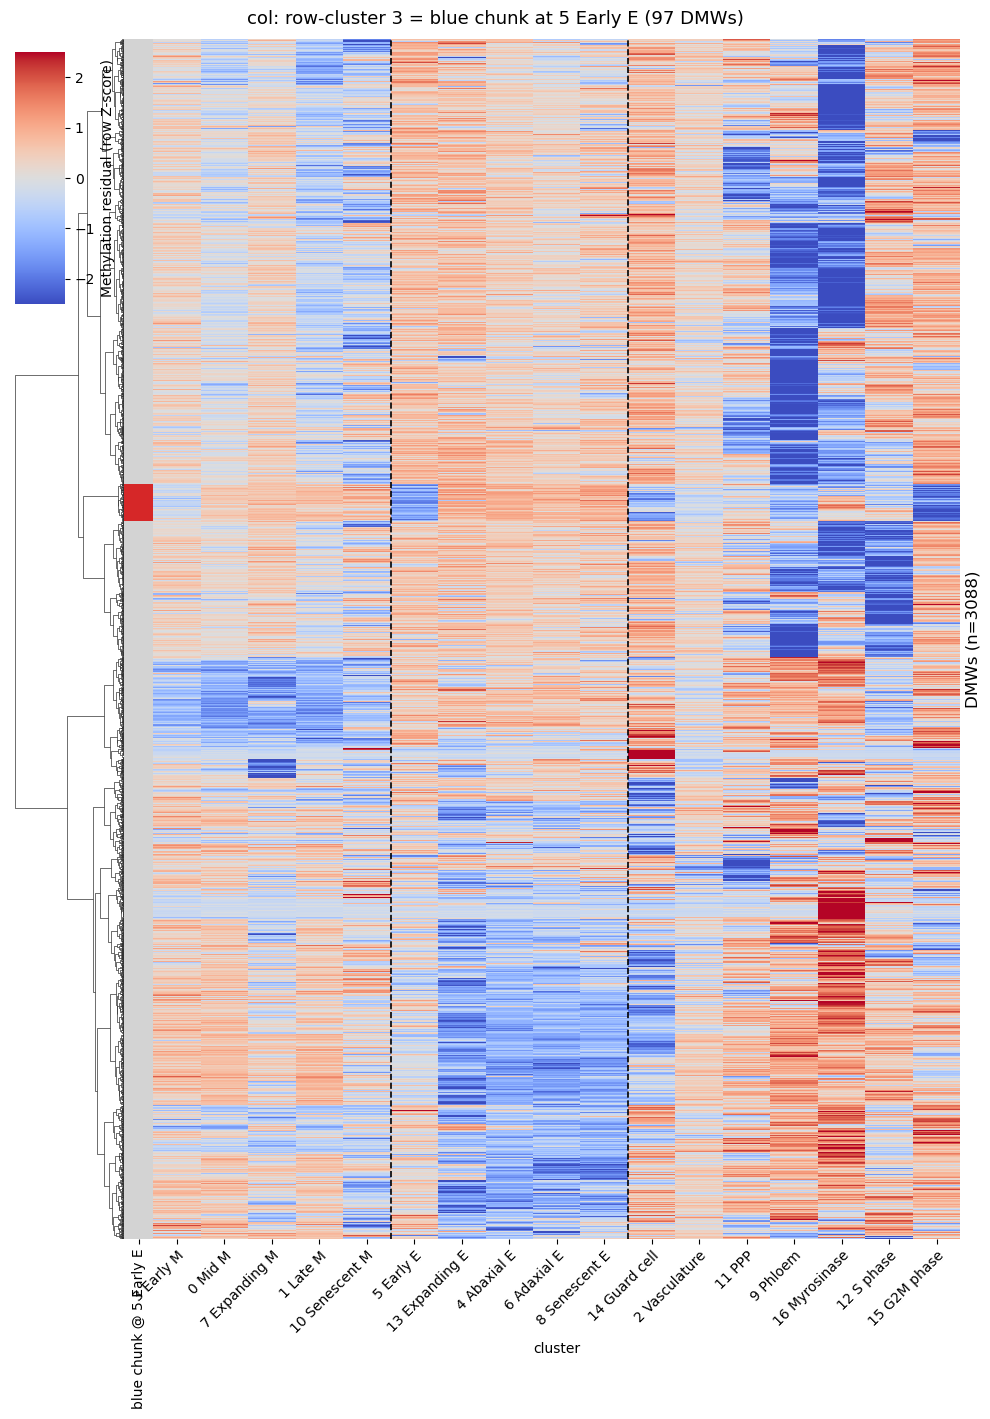

Saved 97 DMWs -> /ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype/col_blue_chunk_5earlyE_dmws.tsv


,chrom,start,end,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
dmw,,,,,,,,,,,,,,,,,,,,
dmw=6199,2,3244601,3244900,-0.185131,0.067072,0.069661,0.091625,0.218973,-0.206497,0.158945,0.176218,0.102689,0.096946,-0.372243,-0.203388,0.143094,-0.171771,0.197594,-0.229507,-0.606865
dmw=6200,2,3245201,3245600,-0.068979,0.020506,0.184207,0.138471,0.202647,-0.438385,0.105457,0.179748,0.087323,0.202931,-0.332486,-0.026816,0.184658,-0.089268,0.084851,0.096524,-0.442782
dmw=6201,2,3254901,3255100,-0.097853,0.050867,0.099800,0.008534,0.015458,-0.170229,0.133021,0.058554,0.057434,-0.042744,0.053101,-0.046781,0.085993,-0.117852,0.000434,-0.175544,-0.263736
dmw=6202,2,3260601,3260800,-0.060711,0.015017,0.078127,0.056224,0.054915,-0.221755,0.112862,0.091106,0.064024,0.074046,-0.177625,-0.086206,-0.054561,-0.206526,-0.029032,0.068783,-0.365048
dmw=6203,2,3263401,3263600,-0.168859,0.011038,0.065901,0.032675,0.028319,-0.097539,0.176405,0.079764,0.032164,0.127477,0.069196,-0.079895,0.115665,-0.072927,-0.124331,-0.185214,-0.294296


In [11]:
# ----- Highlight the selected cluster on the col heatmap and save the DMW list -----
row_colors = row_clusters.map(
    lambda c: "tab:red" if c == target_cluster else "lightgrey"
).rename(f"blue chunk @ {TARGET_COL}")

g = sns.clustermap(
    vis_col,
    cmap="coolwarm", center=0,
    row_linkage=row_linkage, col_cluster=False,
    row_colors=row_colors,
    yticklabels=False, figsize=(10, 14),
    cbar_kws={"label": "Methylation residual (row Z-score)"},
    dendrogram_ratio=(0.12, 0.0),
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(),
                             rotation=45, ha="right", rotation_mode="anchor")
g.ax_heatmap.set_ylabel(f"DMWs (n={vis_col.shape[0]})", fontsize=12)
g.fig.suptitle(f"col: row-cluster {target_cluster} = blue chunk at {TARGET_COL} "
               f"({len(target_dmws)} DMWs)", fontsize=13, y=1.01)

mesophyll_end = sum(1 for c in vis_col.columns if c.endswith(" M"))
epidermis_end = mesophyll_end + sum(1 for c in vis_col.columns if c.endswith(" E"))
for pos in (mesophyll_end, epidermis_end):
    g.ax_heatmap.axvline(pos, color="black", lw=1.2, linestyle="--")

out_png = f"{FIG_OUTDIR}/col_blue_chunk_5earlyE.png"
g.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"Saved highlight heatmap: {out_png}")
plt.show()

# ----- Save the selected DMWs with genomic coordinates + col residuals -----
coords = pd.DataFrame({
    "chrom": mcds["dmw_chrom"].values.astype(str),
    "start": mcds["dmw_start"].values.astype(int),
    "end":   mcds["dmw_end"].values.astype(int),
}, index=mcds.get_index("dmw"))
coords.index.name = "dmw"

blue_chunk_df = coords.join(col_res.loc[target_dmws], how="right")
out_tsv = f"{OUTDIR}/col_blue_chunk_5earlyE_dmws.tsv"
blue_chunk_df.to_csv(out_tsv, sep="\t")
print(f"Saved {len(blue_chunk_df)} DMWs -> {out_tsv}")
display(blue_chunk_df.head())

## Side-by-side: col / rdd / met (col-0 dendrogram order)

Re-plots all three genotypes with rows ordered by the col-0 Ward / Euclidean dendrogram, so any blue or red band in the col panel maps onto the exact same rows in rdd and met. The 8 rdd rows that fail per-genotype coverage are dropped from all three for a strictly row-aligned comparison.

Rows used: 3080  (dropped 8 for NaN in some genotype)
Saved side-by-side comparison: /ceph/MethDev/pbio/kay/figures/heatmaps/col_rdd_met_residuals_col_order.png


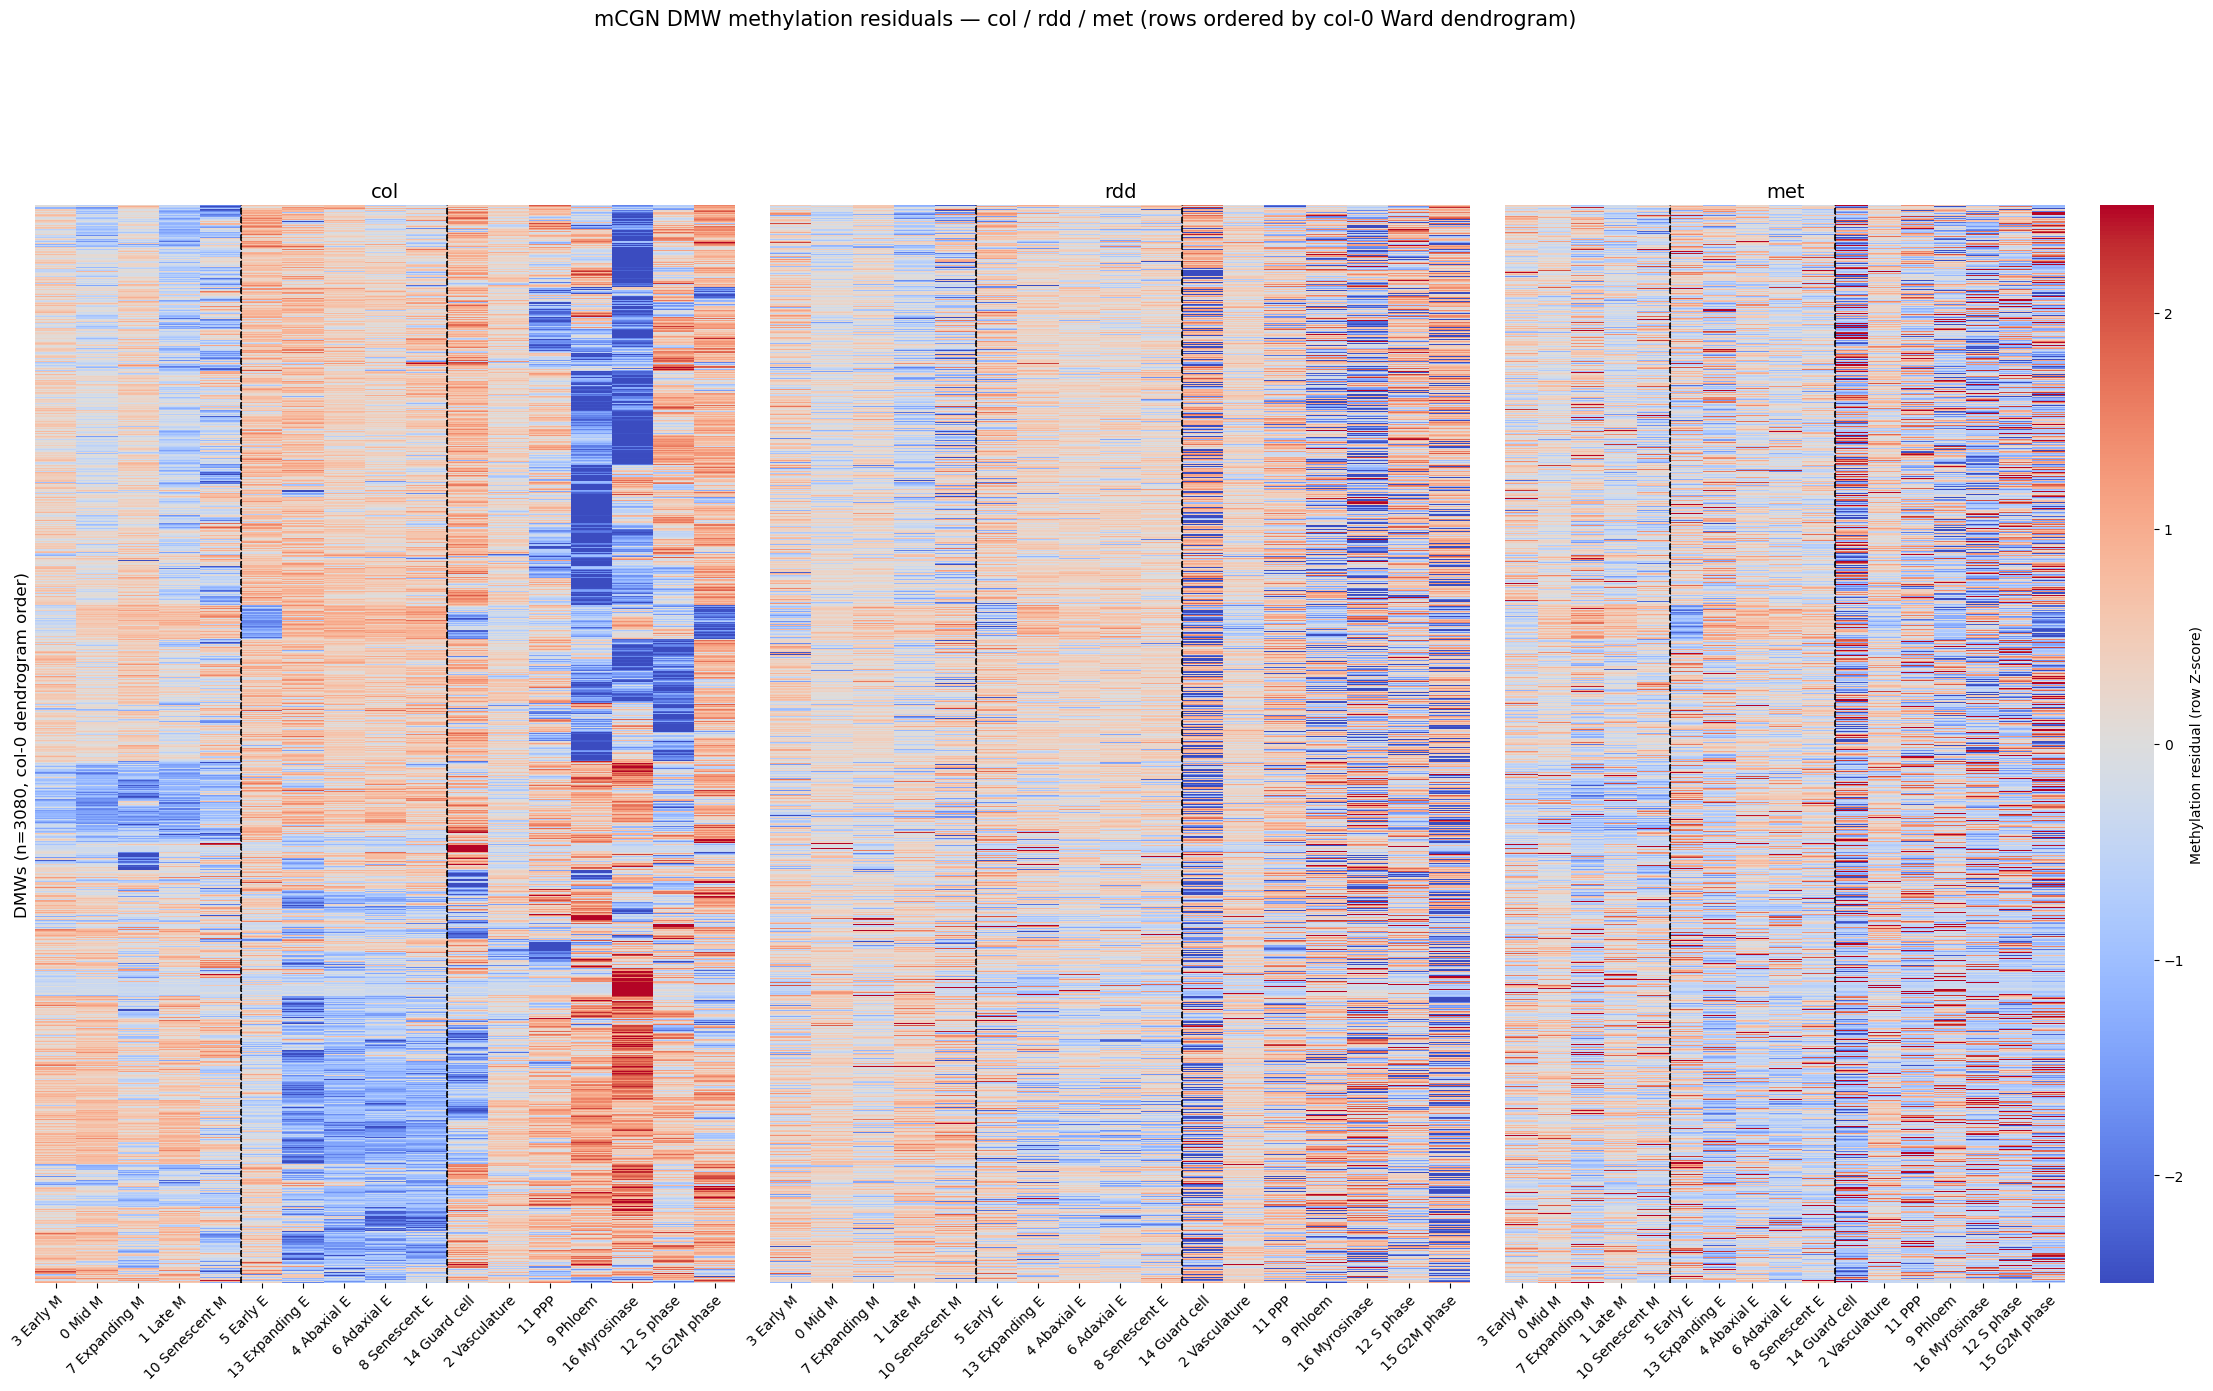

In [12]:
from scipy.cluster.hierarchy import linkage, leaves_list

# Col-0 leaf order, computed identically to the col clustermap above
# (full 3088-row matrix, Ward / Euclidean on row-z-scored clipped residuals).
col_vis  = res_relabeled["col"].apply(zscore, axis=1).clip(-2.5, 2.5)
col_link = linkage(col_vis.values, method="ward", metric="euclidean")
col_order_full = col_vis.index[leaves_list(col_link)]

# Restrict to rows with non-NaN in all three genotypes, preserving col order
# so rdd / met line up row-for-row with the col panel.
nan_free = set(col_vis.index)
for g in GENOTYPES:
    nan_free &= set(res_relabeled[g].dropna().index)
ordered_rows = pd.Index([r for r in col_order_full if r in nan_free])
print(f"Rows used: {len(ordered_rows)}  "
      f"(dropped {len(col_order_full) - len(ordered_rows)} for NaN in some genotype)")

fig, axes = plt.subplots(1, 3, figsize=(28, 14), sharey=True,
                        gridspec_kw={"wspace": 0.05})

for ax, g in zip(axes, GENOTYPES):
    z = res_relabeled[g].loc[ordered_rows].apply(zscore, axis=1).clip(-2.5, 2.5)
    sns.heatmap(
        z, ax=ax,
        cmap="coolwarm", center=0, vmin=-2.5, vmax=2.5,
        yticklabels=False,
        cbar=(g == GENOTYPES[-1]),
        cbar_kws={"label": "Methylation residual (row Z-score)"},
    )
    ax.set_title(g, fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(),
                       rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xlabel("")

    mesophyll_end = sum(1 for c in z.columns if c.endswith(" M"))
    epidermis_end = mesophyll_end + sum(1 for c in z.columns if c.endswith(" E"))
    for pos in (mesophyll_end, epidermis_end):
        ax.axvline(pos, color="black", lw=1.2, linestyle="--")
    for i, col_name in enumerate(z.columns):
        if "Senescent M" in col_name or "Senescent E" in col_name:
            ax.axvline(i + 1, color="black", lw=0.8, linestyle=":")

axes[0].set_ylabel(f"DMWs (n={len(ordered_rows)}, col-0 dendrogram order)", fontsize=12)
fig.suptitle(f"m{MC_TYPE} DMW methylation residuals — col / rdd / met "
             f"(rows ordered by col-0 Ward dendrogram)",
             fontsize=15, y=1.02)

out_png = f"{FIG_OUTDIR}/col_rdd_met_residuals_col_order.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"Saved side-by-side comparison: {out_png}")
plt.show()

## Col-0-anchored residuals (inter-genotype baseline preserved)

Recomputes the residual as `obs_p[geno] − p0(col)`, where `p0(col)` is built from col-0's per-cluster `deltas` *and* per-DMW `pbar`. Every genotype is now scored against the same reference, so:

- col panel sits near zero (its observed methylation matches its own null)
- **rdd** shifts red — over-methylated relative to col (RdDM-pathway demethylases are knocked out)
- **met** shifts blue — under-methylated relative to col (MET1 CG methyltransferase is knocked out)

Plotted **un-z-scored** on a shared ±0.5 diverging scale, with the same col-0 row order as the previous panel for direct row-for-row comparison. Cluster-specific structure remains visible as modulation on top of the bulk shift; the per-panel mean residual (printed in each title) is the bulk shift itself.

Saved col-0-anchored side-by-side: /ceph/MethDev/pbio/kay/figures/heatmaps/col_rdd_met_residuals_col_anchored.png


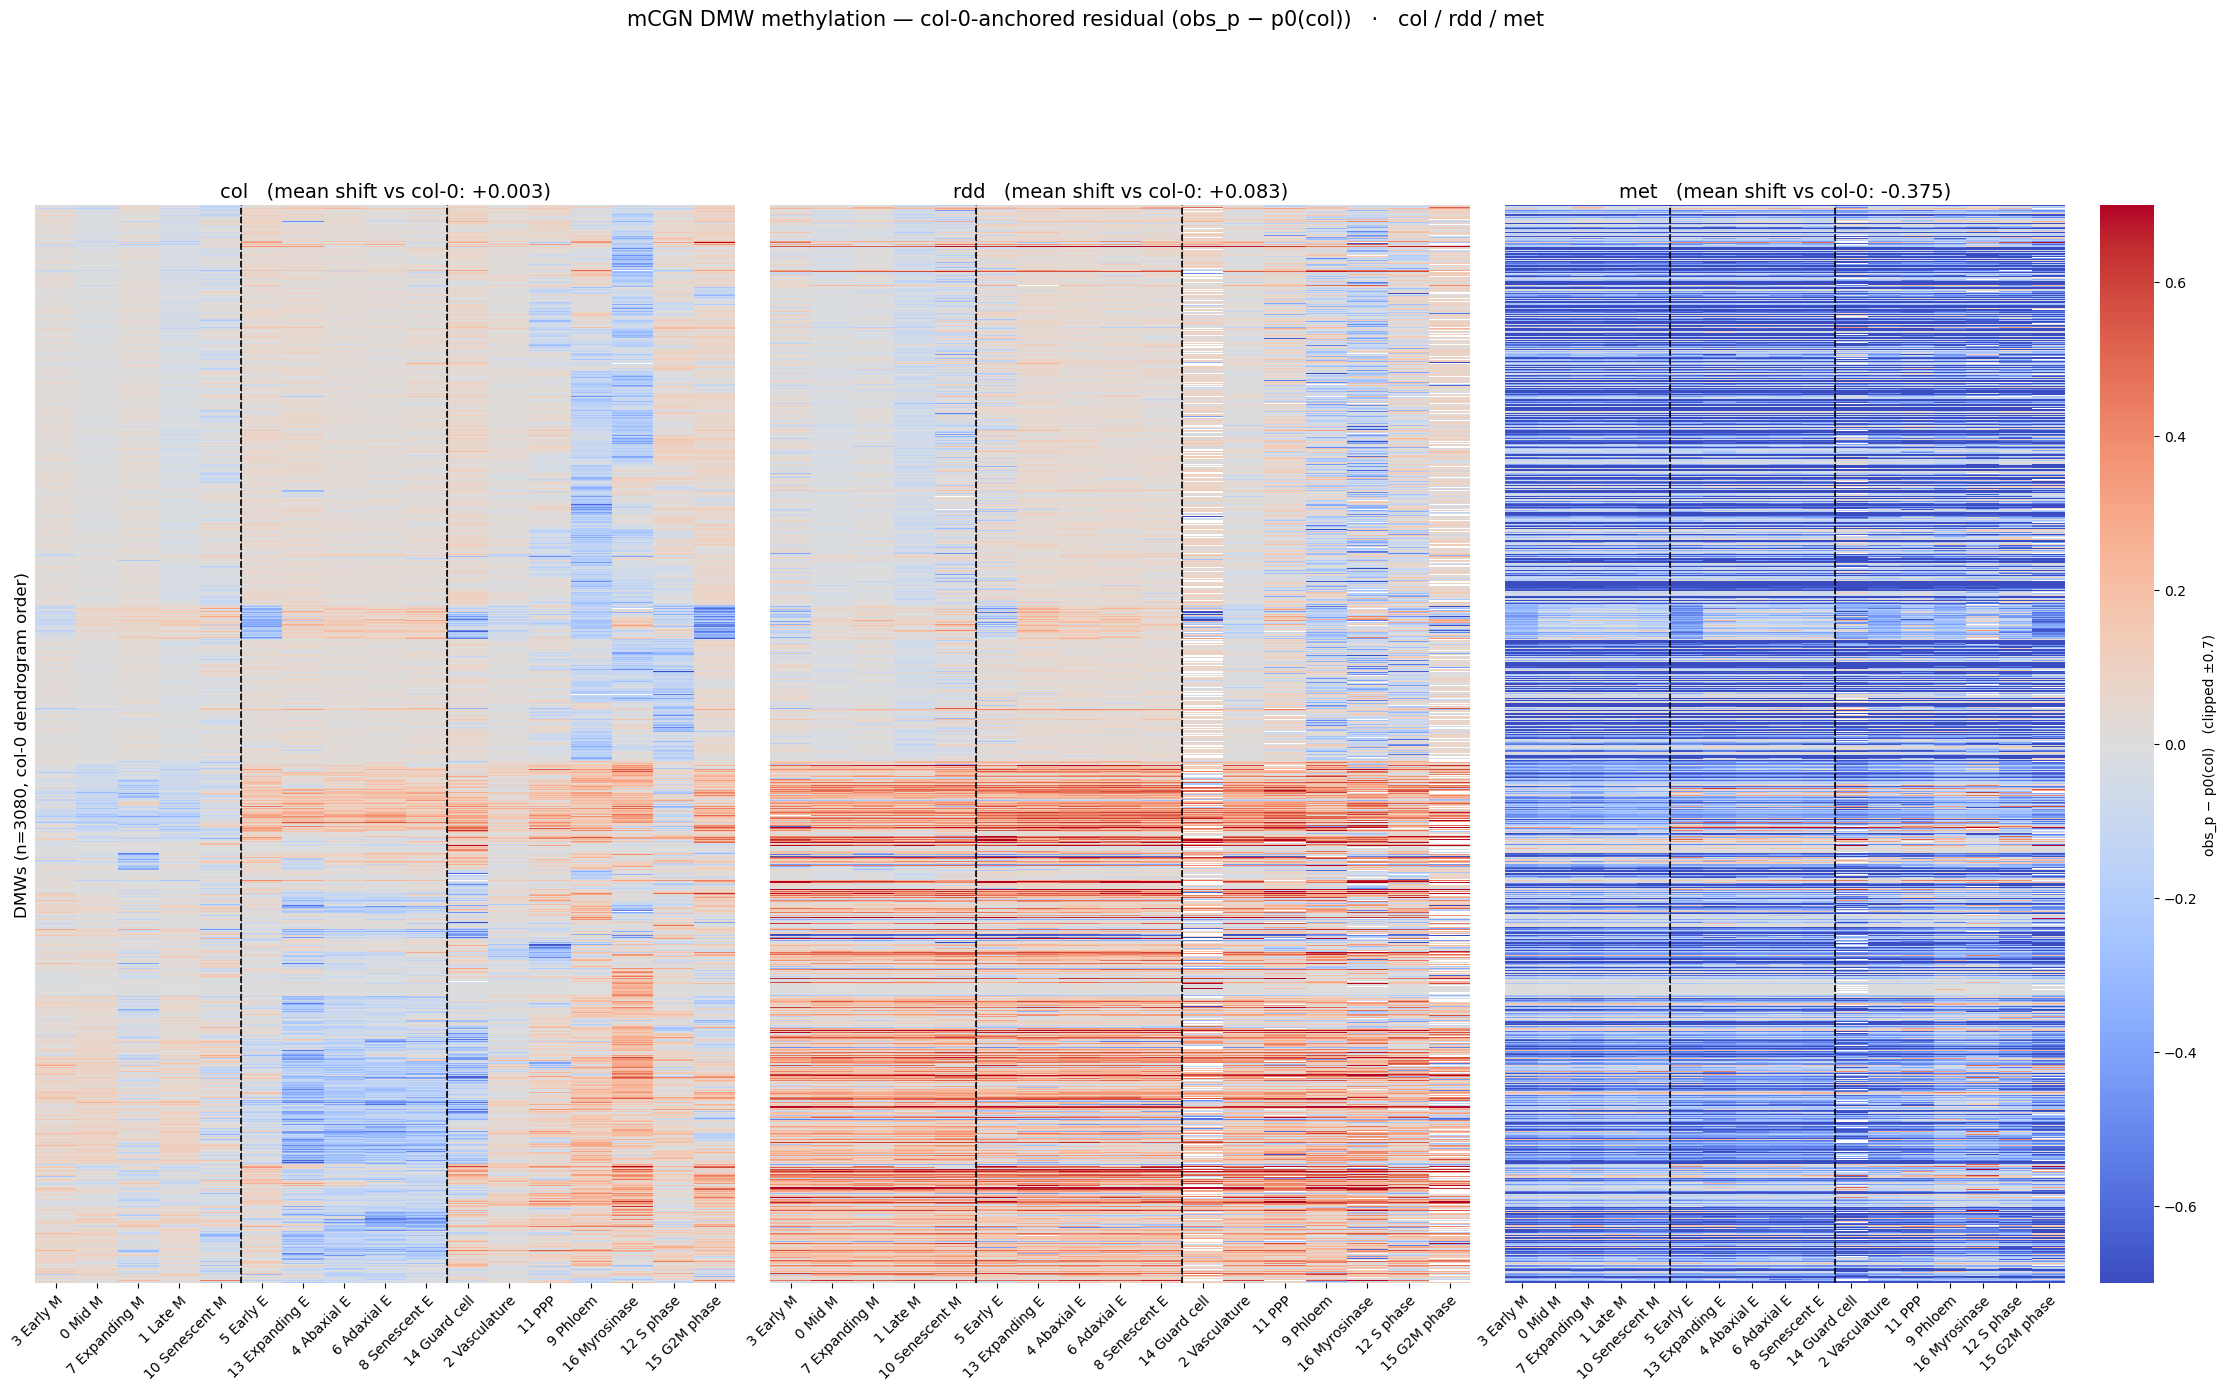

In [17]:
# ----- Fit col-0's null model: per-cluster deltas + per-DMW pbar -----
col_c, col_m = per_cluster_sums("col")
col_global_c = col_c.sum(axis=0)
col_global_m = col_m.sum(axis=0)
col_global_p = col_global_c / col_global_m
col_d        = logit(np.clip(col_global_p, 1e-6, 1 - 1e-6))
col_deltas   = col_d - np.average(col_d, weights=col_global_m)
col_dmw_c    = col_c.sum(axis=1)
col_dmw_m    = col_m.sum(axis=1)
col_pbar     = np.clip(col_dmw_c / col_dmw_m, 1e-6, 1 - 1e-6)
col_p0       = pd.DataFrame(
    expit(logit(col_pbar).values[:, None] + col_deltas.values[None, :]),
    index=col_c.index, columns=col_c.columns,
)

# ----- obs_p[geno] - p0(col), with per-genotype coverage filter, anchored to canonical_rows -----
anchored = {}
for g in GENOTYPES:
    c, m  = per_cluster_sums(g)
    obs_p = (c / m.replace(0, np.nan))
    valid = m.sum(axis=1) >= MIN_COV
    obs_p = obs_p.where(valid, np.nan)
    res   = obs_p - col_p0                    # broadcasts on aligned (dmw, cluster)
    anchored[g] = relabel(res.reindex(canonical_rows))

# ----- Side-by-side, col-0 row order, shared ±VMAX diverging scale -----
VMAX = 0.7

fig, axes = plt.subplots(1, 3, figsize=(28, 14), sharey=True,
                        gridspec_kw={"wspace": 0.05})

for ax, g in zip(axes, GENOTYPES):
    mat = anchored[g].loc[ordered_rows]       # ordered_rows defined in previous cell
    sns.heatmap(
        mat, ax=ax,
        cmap="coolwarm", center=0, vmin=-VMAX, vmax=VMAX,
        yticklabels=False,
        cbar=(g == GENOTYPES[-1]),
        cbar_kws={"label": f"obs_p − p0(col)   (clipped ±{VMAX})"},
    )
    bulk_shift = float(np.nanmean(mat.values))
    ax.set_title(f"{g}   (mean shift vs col-0: {bulk_shift:+.3f})", fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(),
                       rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xlabel("")
    mesophyll_end = sum(1 for c in mat.columns if c.endswith(" M"))
    epidermis_end = mesophyll_end + sum(1 for c in mat.columns if c.endswith(" E"))
    for pos in (mesophyll_end, epidermis_end):
        ax.axvline(pos, color="black", lw=1.2, linestyle="--")
    for i, col_name in enumerate(mat.columns):
        if "Senescent M" in col_name or "Senescent E" in col_name:
            ax.axvline(i + 1, color="black", lw=0.8, linestyle=":")

axes[0].set_ylabel(f"DMWs (n={len(ordered_rows)}, col-0 dendrogram order)", fontsize=12)
fig.suptitle(f"m{MC_TYPE} DMW methylation — col-0-anchored residual "
             f"(obs_p − p0(col))   ·   col / rdd / met",
             fontsize=15, y=1.02)

out_png = f"{FIG_OUTDIR}/col_rdd_met_residuals_col_anchored.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"Saved col-0-anchored side-by-side: {out_png}")
plt.show()